## Import all libraries

In [184]:
import os 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import(
    StandardScaler,
    LabelEncoder
)
from sklearn.model_selection import(
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    roc_auc_score,
    precision_score,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)


## Load datasets

In [185]:
cwd = os.getcwd()
data_dir_path = os.path.join(cwd, 'data')

df_train, df_test = (
    pd.read_csv(os.path.join(data_dir_path, 'train.csv')).set_index('PassengerId'),
    pd.read_csv(os.path.join(data_dir_path, 'test.csv')).set_index('PassengerId')
)

## EDA

#### Data profiling

In [186]:
df_train.head()

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
PassengerId,,,,,,,,,,,,,
0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [187]:
df_train.info()

<class 'pandas.DataFrame'>
Index: 8693 entries, 0001_01 to 9280_02
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8492 non-null   str    
 1   CryoSleep     8476 non-null   object 
 2   Cabin         8494 non-null   str    
 3   Destination   8511 non-null   str    
 4   Age           8514 non-null   float64
 5   VIP           8490 non-null   object 
 6   RoomService   8512 non-null   float64
 7   FoodCourt     8510 non-null   float64
 8   ShoppingMall  8485 non-null   float64
 9   Spa           8510 non-null   float64
 10  VRDeck        8505 non-null   float64
 11  Name          8493 non-null   str    
 12  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(4)
memory usage: 891.4+ KB


In [188]:
df_train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [189]:
df_train.dtypes

HomePlanet          str
CryoSleep        object
Cabin               str
Destination         str
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name                str
Transported        bool
dtype: object

In [190]:
df_train.isna().sum()

HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [191]:
df_train.duplicated().sum()

np.int64(0)

In [192]:
df_train.head()

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
PassengerId,,,,,,,,,,,,,
0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


#### Fillin and deleting Nan data

In [193]:
def preprocessing_df(df):
    df_ = df.copy()    

    df_cleaned = (df_
        .drop(['Name', 'Cabin'], axis=1)
        .assign(
            HomePlanet=lambda d: d['HomePlanet'].fillna(d['HomePlanet'].mode()[0]),
            Destination=lambda d: d['Destination'].fillna(d['Destination'].mode()[0]),
            CryoSleep=lambda d: d['CryoSleep'].fillna(d['CryoSleep'].mode()[0]),
            VIP=lambda d: d['VIP'].fillna(d['VIP'].mode()[0]),
            Age=lambda d: d['Age'].fillna(d['Age'].median())
        )
        .fillna(0)
    )
    

    cols_to_int = ['CryoSleep', 'VIP'] 
    df_cleaned[cols_to_int] = df_cleaned[cols_to_int].astype(int)

    return df_cleaned

In [194]:
df_train_cleaned = preprocessing_df(df_train)
df_train_cleaned.sample(5, random_state=20)

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
PassengerId,,,,,,,,,,,
8616_02,Mars,1,55 Cancri e,20.0,0,0.0,0.0,0.0,0.0,0.0,True
7200_01,Europa,0,TRAPPIST-1e,37.0,0,300.0,3434.0,0.0,1.0,171.0,True
7806_01,Earth,0,55 Cancri e,24.0,0,0.0,688.0,0.0,0.0,1.0,False
3018_01,Earth,0,TRAPPIST-1e,32.0,0,0.0,49.0,2.0,639.0,0.0,False
3868_05,Earth,0,55 Cancri e,16.0,0,0.0,0.0,623.0,40.0,209.0,True


<Axes: >

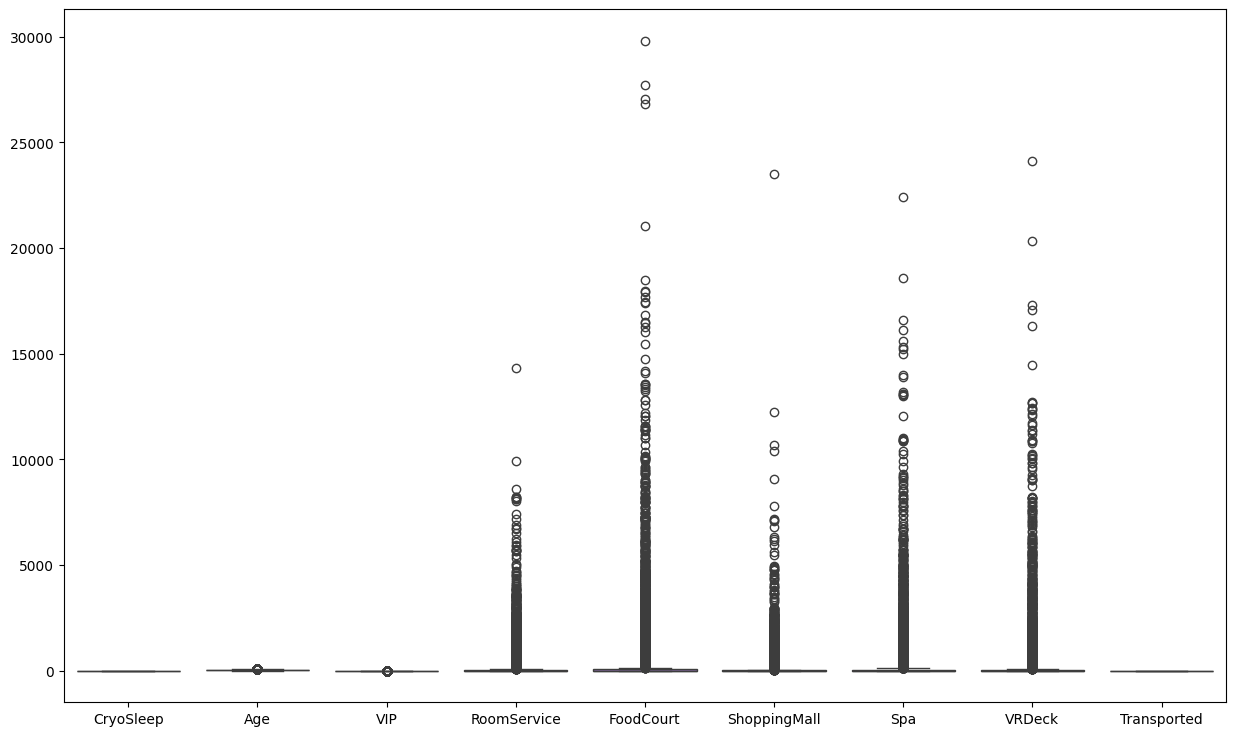

In [195]:
plt.figure(figsize=(15, 9))
sns.boxplot(data=df_train_cleaned)

#### Heat map

<Axes: >

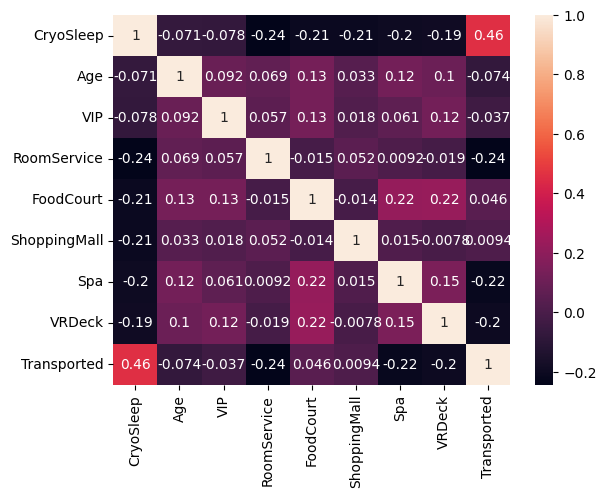

In [196]:
sns.heatmap(df_train_cleaned.corr(numeric_only=True), annot=True)

<Axes: xlabel='Transported', ylabel='count'>

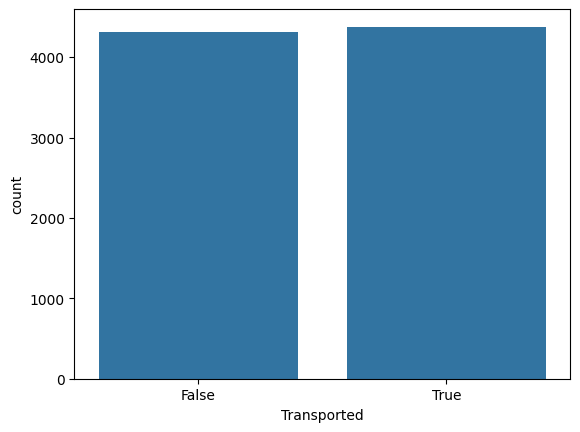

In [197]:
sns.countplot(data=df_train_cleaned, x='Transported')

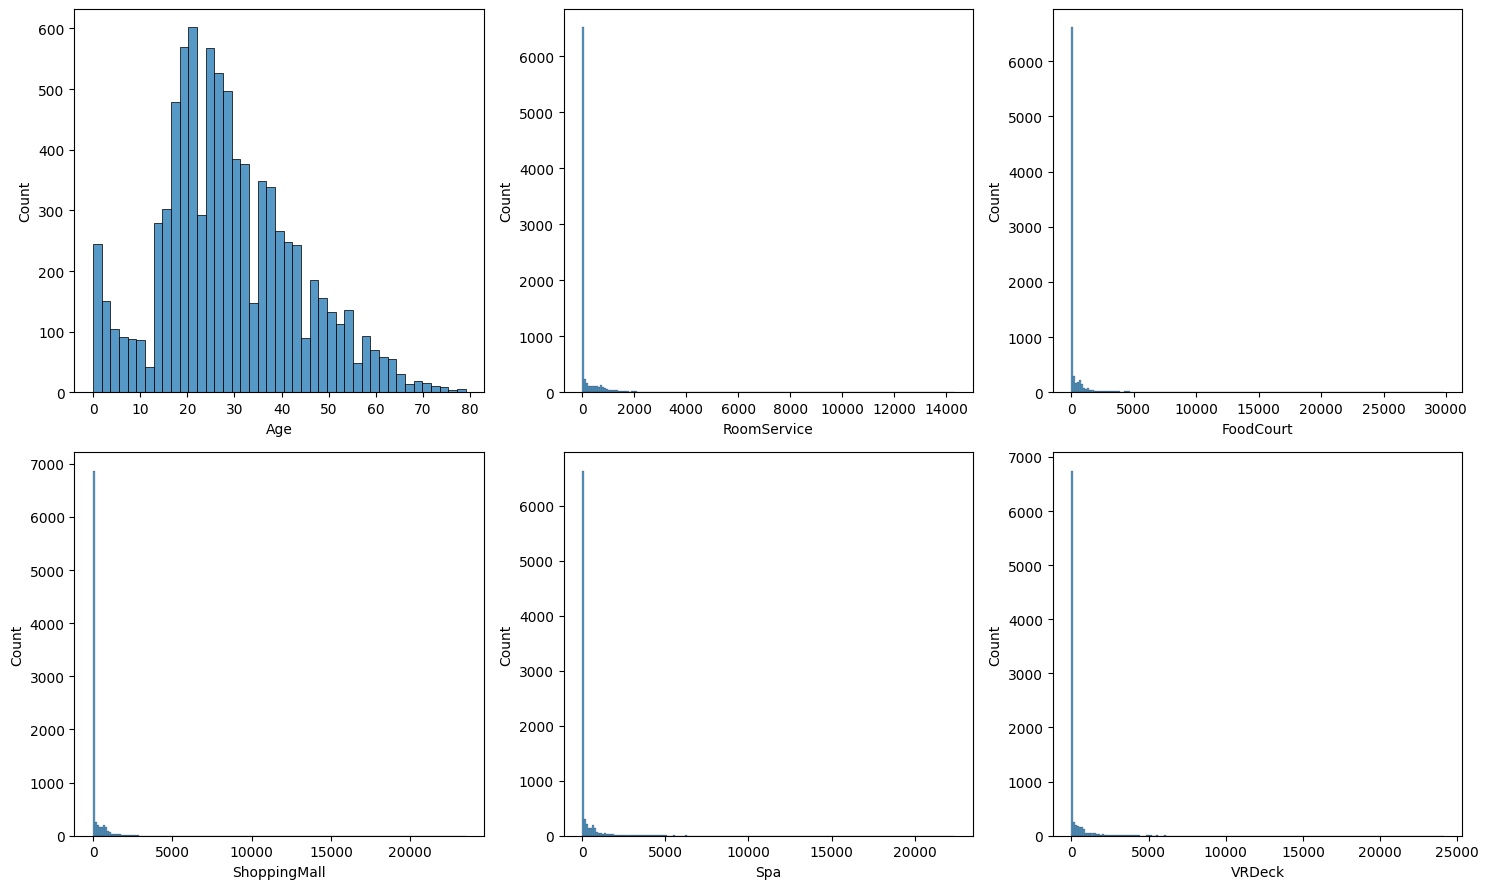

In [198]:
cols_to_plot_distribut = ['Age', 'RoomService',	'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 9))
for ax, col in zip(axs.flatten(), cols_to_plot_distribut):
    sns.histplot(data=df_train, x=col, ax=ax)
    

fig.tight_layout()

#### Encoding str data

In [199]:
df_train_ready = pd.get_dummies(df_train_cleaned, columns=['HomePlanet', 'Destination'], dtype=int)
df_train_ready.head()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
PassengerId,,,,,,,,,,,,,,,
0001_01,0,39.0,0,0.0,0.0,0.0,0.0,0.0,False,0,1,0,0,0,1
0002_01,0,24.0,0,109.0,9.0,25.0,549.0,44.0,True,1,0,0,0,0,1
0003_01,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,False,0,1,0,0,0,1
0003_02,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,False,0,1,0,0,0,1
0004_01,0,16.0,0,303.0,70.0,151.0,565.0,2.0,True,1,0,0,0,0,1


## Using Random Forest and XGBoost models


In [200]:
X = df_train_ready.drop('Transported', axis=1)
y = df_train_ready['Transported']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [201]:
y_train

PassengerId
5981_01    False
5606_01     True
0515_01     True
1425_02     True
5713_01     True
           ...  
6076_01     True
5537_01    False
5756_06    False
0925_01    False
7775_01    False
Name: Transported, Length: 6519, dtype: bool

#### Random Forest

In [202]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_pipeline = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier())
    ]
)

grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid={
        'model__criterion' : ['gini', 'entropy', 'log_loss'],
        'model__n_estimators': [50, 100, 150, 200, 300, 400],
        'model__max_depth': [4, 5, 7, 10],
    },
    n_jobs=-1,
    cv=cv,
    scoring='accuracy'

)
grid_search_rf.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['gini', 'entropy', ...], 'model__max_depth': [4, 5, ...], 'model__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation ti

#### Best params

In [203]:
print(grid_search_rf.best_params_)
print(grid_search_rf.best_score_)

{'model__criterion': 'gini', 'model__max_depth': 10, 'model__n_estimators': 50}
0.7981276101869683


#### Metrics

In [204]:
# FITTED model with best params
rf_model = grid_search_rf.best_estimator_
y_pred = rf_model.predict(X_test)
y_proba_pred = rf_model.predict_proba(X_test)[:, 1]
feature_names = rf_model.feature_names_in_

In [205]:
def plot_metrics(y_true, y_pred,  proba, feature_importance, feature_names):
    fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(15, 9))

    PrecisionRecallDisplay.from_predictions(y_true, proba, ax=axs[0])
    axs[0].set_title('Precision x Recall')
    
    RocCurveDisplay.from_predictions(y_true, proba, ax=axs[1])
    axs[1].set_title('ROC-Auc')

    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=axs[2])
    axs[2].set_title('Conf-Mat')

    sns.barplot(x=feature_importance, y=feature_names, ax=axs[3])


    fig.tight_layout()

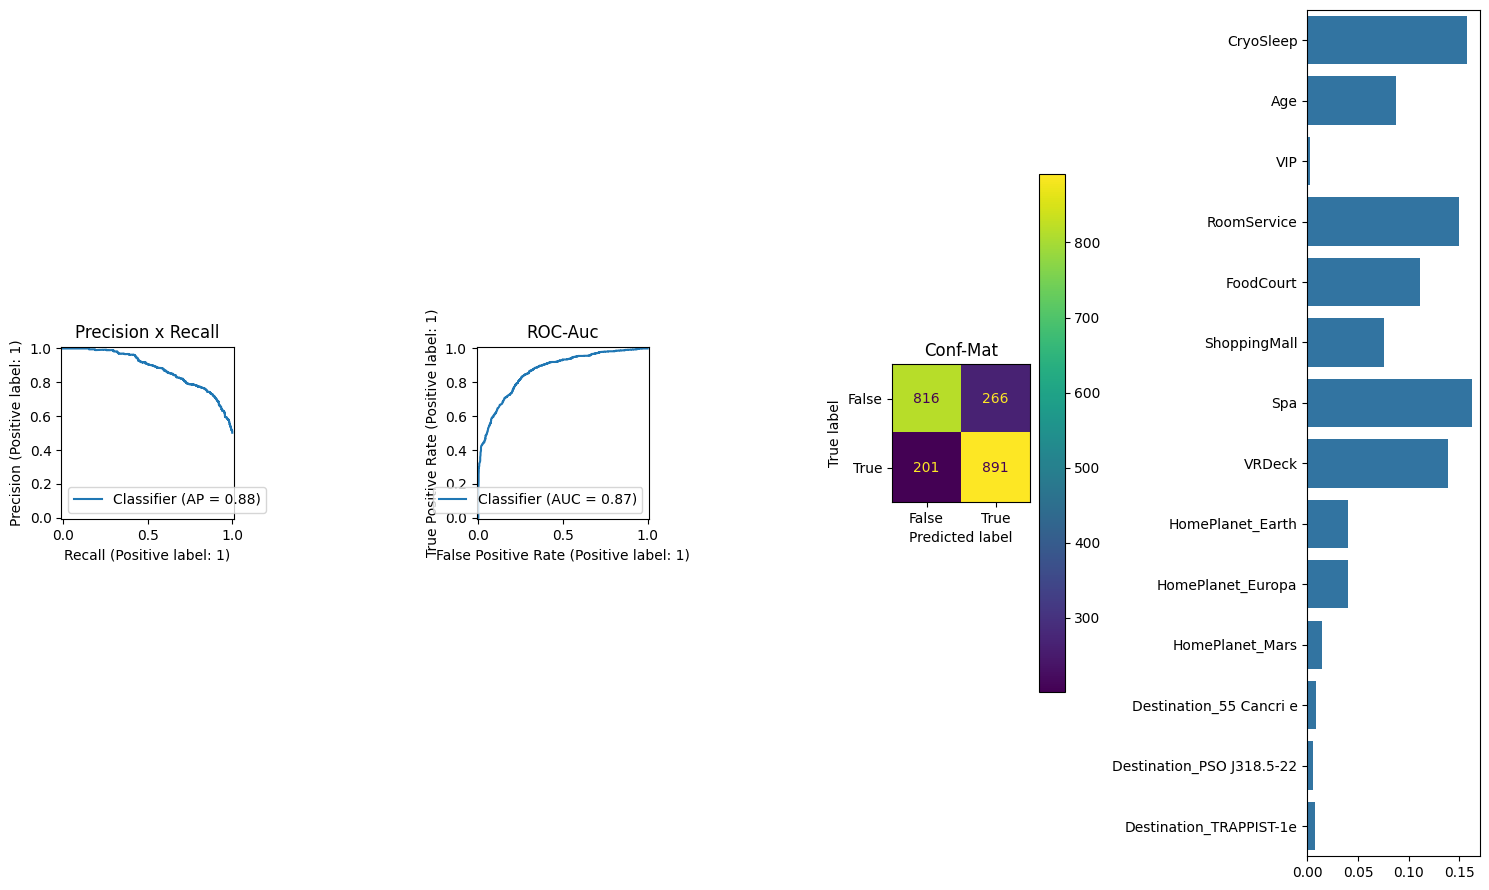

In [206]:
f_importances = rf_model['model'].feature_importances_
plot_metrics(y_test, y_pred, y_proba_pred, f_importances, feature_names)

In [207]:
print(f'Accuracy train: {rf_model.score(X_train, y_train)}')
print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
print(f'Precision: {precision_score(y_test, y_pred)}')
print(f'Recall: {recall_score(y_test, y_pred)}') 

Accuracy train: 0.8484430127320142
Accuracy: 0.7851885924563018
Precision: 0.77009507346586
Recall: 0.8159340659340659


## XGBOOST model

In [208]:
XGB_pipeline = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('model', XGBClassifier())
    ]
)

grid_search_XBG = GridSearchCV(
    estimator=XGB_pipeline,
    param_grid={
        'model__n_estimators': [150, 200, 300],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [4, 5, 7],
        'model__reg_alpha': [0, 0.01, 0.1],
        'model__reg_lambda': [1, 1.5, 2],
    
    },
    n_jobs=-1,
    cv=cv,
    scoring='accuracy'

)
grid_search_XBG.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [4, 5, ...], 'model__n_estimators': [150, 200, ...], 'model__reg_alpha': [0, 0.01, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, th

In [209]:
print(grid_search_XBG.best_params_)
print(grid_search_XBG.best_score_)

{'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 150, 'model__reg_alpha': 0.01, 'model__reg_lambda': 1.5}
0.7958272321071242


#### Mectrics

In [210]:
# FITTED model with best params
XGB_model = grid_search_XBG.best_estimator_
y_pred = XGB_model.predict(X_test)
y_proba_pred = XGB_model.predict_proba(X_test)[:, 1]
feature_names = XGB_model.feature_names_in_
f_importances = XGB_model['model'].feature_importances_

In [211]:
print(f'Accuracy train: {XGB_model.score(X_train, y_train)}')
print(f'Accuracy test: {accuracy_score(y_test, y_pred)}')
print(f'Precision: {precision_score(y_test, y_pred)}')
print(f'Recall: {recall_score(y_test, y_pred)}') 

Accuracy train: 0.8206780181009358
Accuracy test: 0.7870285188592456
Precision: 0.7636211232187762
Recall: 0.8342490842490843


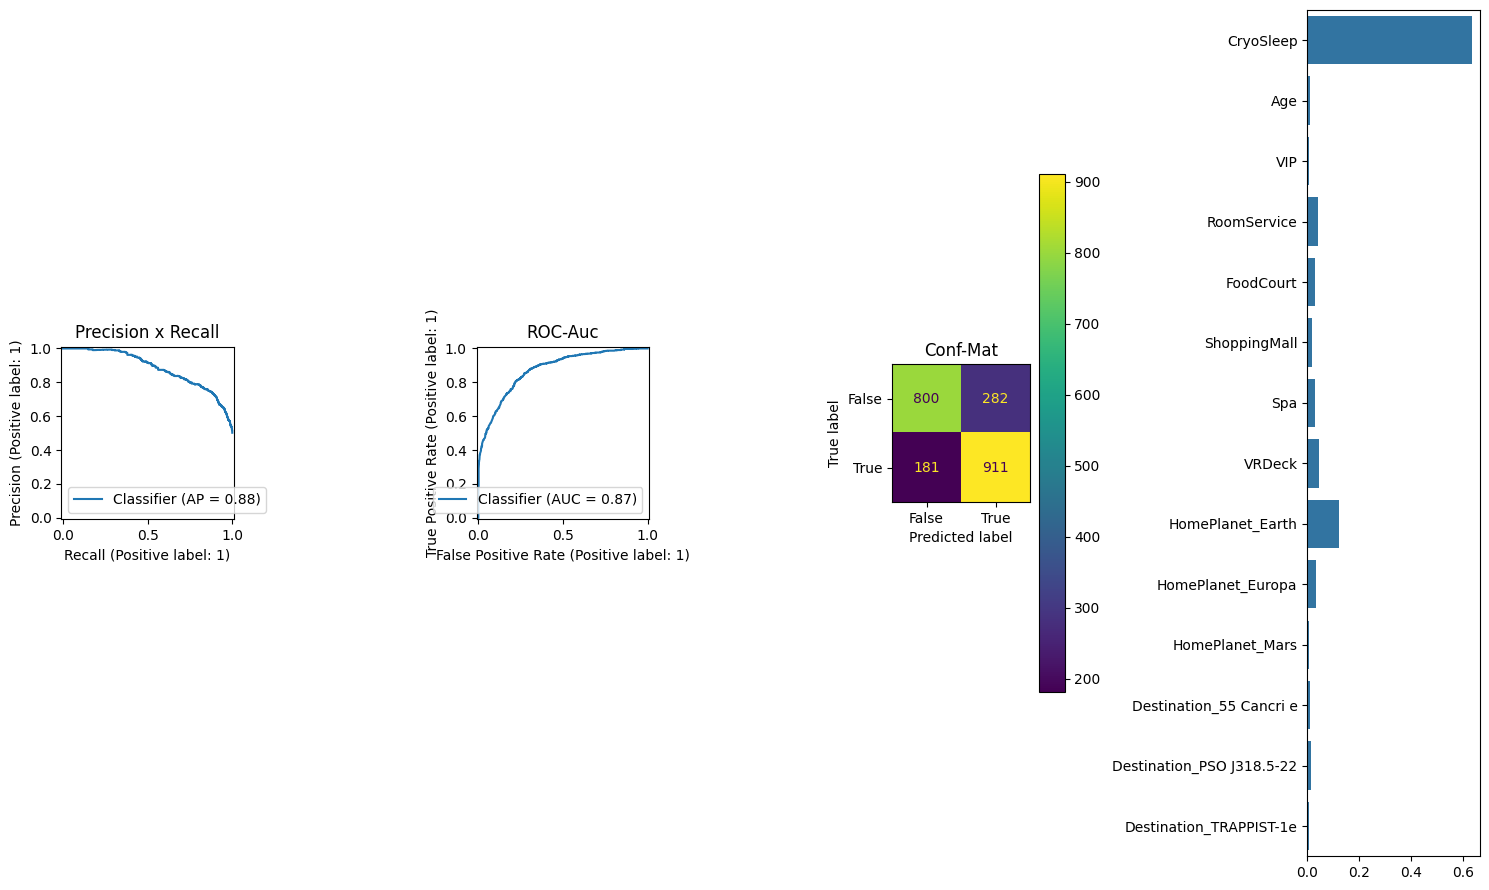

In [212]:
plot_metrics(y_test, y_pred, y_proba_pred, f_importances, feature_names)

#### Predict for Kaggle submission

In [213]:
df_test_clean = preprocessing_df(df_test)

df_test_ready = pd.get_dummies(df_test_clean, columns=['HomePlanet', 'Destination'], dtype=int)
df_test_ready.head()


rf_kaggle = rf_model.predict(df_test_ready)
XGB_kaggle = XGB_model.predict(df_test_ready)

# Random Forest predict
submission1 = pd.read_csv(os.path.join(data_dir_path, 'sample_submission.csv'))
submission1['Transported'] = rf_kaggle.astype(bool)
submission1.to_csv('submission1.csv', index=False)

#XGBOOST predict
submission2 = pd.read_csv(os.path.join(data_dir_path, 'sample_submission.csv'))
submission2['Transported'] = XGB_kaggle.astype(bool)
submission2.to_csv('submission2.csv', index=False)

(np.float64(-0.5), np.float64(2449.5), np.float64(511.5), np.float64(-0.5))

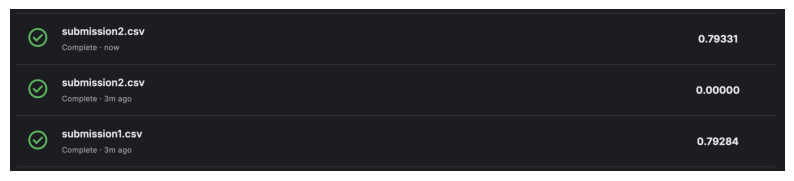

In [214]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


plt.figure(figsize=(10, 4))
img = mpimg.imread(os.path.join(data_dir_path, 'ready.png'))
plt.imshow(img)
plt.axis('off')